# 03 · Historical risk monitoring

**Objective:** measure transaction volumes, alert workload and retrospective detection performance over time.

This historical replay uses the validation predictions saved by Notebook 02, with the model and threshold fixed.
The period was also used for model and threshold selection, so the results do not establish stability on new data.

| Available at scoring | Requires confirmed fraud labels |
|---|---|
| Transactions, alerts, alert rate, amount/type mix, score distribution | Fraud rate, precision, recall, false alerts and missed fraud |

Labels are supplied retrospectively without confirmation timestamps. The replay cannot reconstruct when an analyst
would have known each outcome. It reports descriptive monitoring metrics without automatic drift or retraining rules.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from analysis_helpers import evaluate

TABLES, FIGURES = Path('reports/tables'), Path('reports/figures')
policy = json.loads(Path('reports/model_summary.json').read_text())
threshold = policy['threshold']
replay = pd.read_csv('artifacts/validation_predictions.csv.gz', float_precision='round_trip')
assert replay.step.between(324, 377).all() and replay.source_row.is_unique
assert np.array_equal(replay.alert, replay.score.ge(threshold))
print(f"Reusing {len(replay):,} validation predictions from {policy['model']}; threshold {threshold:.2f}.")

Reusing 410,437 validation predictions from Small decision tree; threshold 0.99.


## 1. Transaction volumes and alert rates

Alert rate is `alerts / transactions` within the same step. A rising percentage can result from fewer transactions,
so read the count and rate together. Steps without observations are retained with zero volume and an undefined rate.

In [2]:
hourly = replay.groupby('step').agg(transactions=('alert', 'size'), alerts=('alert', 'sum'))
hourly = hourly.reindex(range(324, 378), fill_value=0)
hourly['alert_rate'] = hourly.alerts / hourly.transactions.replace(0, np.nan)
display(hourly.head())
hourly.to_csv(TABLES / 'monitoring_hourly.csv', index_label='step')

,transactions,alerts,alert_rate
step,,,
324,13214,23,0.001741
325,12706,3,0.000236
326,11983,11,0.000918
327,11695,9,0.000770
328,12235,19,0.001553


## 2. Performance by time block and transaction type

Blocks contain up to 24 simulation steps, aligned to step 1. The first and last blocks can be partial;
their boundaries and counts are shown. Compare rates carefully when fraud counts are small.
Missing precision means there were no alerts; missing recall means there were no labelled fraud transactions.

In [3]:
replay['block'] = (replay.step - 1) // 24
rows = []
for block, group in replay.groupby('block'):
    rows.append({'first_step': max(int(block * 24 + 1), 324),
                 'last_step': min(int((block + 1) * 24), 377),
                 **evaluate(group.isFraud, group.score, threshold),
                 'median_amount': group.amount.median(), 'p90_amount': group.amount.quantile(0.90),
                 'transfer_share': group.type.eq('TRANSFER').mean(),
                 'median_score': group.score.median(), 'p90_score': group.score.quantile(0.90)})
blocks = pd.DataFrame(rows)
by_type = pd.DataFrame([
    {'type': name, **evaluate(group.isFraud, group.score, threshold)}
    for name, group in replay.groupby('type')
])
display(blocks[['first_step', 'last_step', 'transactions', 'fraud', 'alerts',
                'fraud_rate', 'precision', 'recall', 'FP', 'FN']].round(4))
display(by_type.round(4))
blocks.to_csv(TABLES / 'monitoring_blocks.csv', index=False)
by_type.to_csv(TABLES / 'monitoring_by_type.csv', index=False)
for column in ['transactions', 'fraud', 'alerts', 'TP', 'FP', 'FN', 'TN']:
    assert blocks[column].sum() == by_type[column].sum() == policy['validation'][column]

,first_step,last_step,transactions,fraud,alerts,fraud_rate,precision,recall,FP,FN
0,324,336,139052,124,107,0.0009,0.1682,0.1452,89,106
1,337,360,173951,250,184,0.0014,0.2500,0.1840,138,204
2,361,377,97434,186,121,0.0019,0.3058,0.1989,84,149


,type,transactions,fraud,alerts,fraud_rate,alert_rate,precision,recall,F1,AP,TP,FP,FN,TN
0,CASH_OUT,329968,280,412,0.0008,0.0012,0.2451,0.3607,0.2919,0.0911,101,311,179,329377
1,TRANSFER,80469,280,0,0.0035,0.0000,NaN,0.0000,0.0000,0.0043,0,0,280,80189


## 3. Monitoring overview

The first three panels use information available at scoring. The final panel uses retrospective labels.
No line in this chart is used to select a new threshold or claim an independent evaluation.

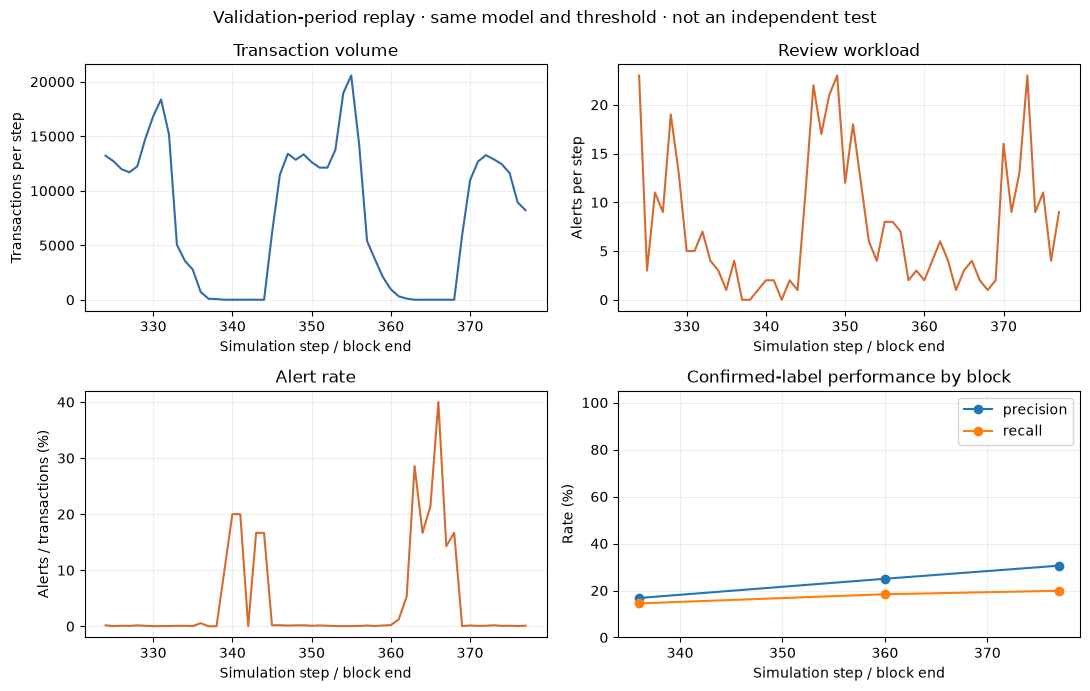

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(hourly.index, hourly.transactions, color='#3569a8')
axes[0, 0].set(title='Transaction volume', ylabel='Transactions per step')
axes[0, 1].plot(hourly.index, hourly.alerts, color='#d36b30')
axes[0, 1].set(title='Review workload', ylabel='Alerts per step')
axes[1, 0].plot(hourly.index, 100 * hourly.alert_rate, color='#d36b30')
axes[1, 0].set(title='Alert rate', ylabel='Alerts / transactions (%)')
for column in ['precision', 'recall']:
    axes[1, 1].plot(blocks.last_step, 100 * blocks[column], marker='o', label=column)
axes[1, 1].set(title='Confirmed-label performance by block', ylabel='Rate (%)', ylim=(0, 105))
axes[1, 1].legend()
for ax in axes.flat:
    ax.set_xlabel('Simulation step / block end')
    ax.grid(alpha=0.2)
fig.suptitle('Validation-period replay · same model and threshold · not an independent test')
fig.tight_layout()
fig.savefig(FIGURES / 'monitoring_overview.png', dpi=150)
plt.show()

## 4. Changes in transaction and score distributions

Medians and 90th percentiles give a simple, partial description of amount and score distributions.
TRANSFER share describes the type mix. These summaries are not formal tests of a distribution change.
Opening balances are outside the monitoring scope because the model excludes them and their simulation semantics remain uncertain.

In [5]:
display(blocks[['first_step', 'last_step', 'transactions', 'median_amount', 'p90_amount',
                'transfer_share', 'median_score', 'p90_score']].round(4))
result = policy['validation']
display(Markdown(
    f"The selected rule generates **{result['alerts']:,} alerts**, equivalent to "
    f"**{10000 * result['alert_rate']:.1f} reviews per 10,000 eligible transactions** in this validation period. "
    f"Known labels identify **{result['FP']:,} false alerts** and **{result['FN']:,} missed fraud transactions**. "
    "These are transaction counts, not unique customers or investigation cases."
))

,first_step,last_step,transactions,median_amount,p90_amount,transfer_share,median_score,p90_score
0,324,336,139052,177885.05,691016.382,0.1966,0.2487,0.624
1,337,360,173951,174090.58,648257.010,0.1942,0.2487,0.624
2,361,377,97434,190248.49,653249.527,0.1987,0.2487,0.624


The selected rule generates **412 alerts**, equivalent to **10.0 reviews per 10,000 eligible transactions** in this validation period. Known labels identify **311 false alerts** and **459 missed fraud transactions**. These are transaction counts, not unique customers or investigation cases.

## Business interpretation

| Observation | First question to investigate |
|---|---|
| Transaction volume falls | Is the extract complete, or has customer activity changed? |
| Alert rate rises | Did alerts increase, or did the denominator shrink? |
| Amount or type mix changes | Is the model now seeing a different mix of activity? |
| Precision falls | Are labels complete, and which legitimate transactions are being flagged? |
| Recall falls | Which confirmed fraud transactions are missed, and are there enough cases to draw a conclusion? |

A false alert can cost reviewer time and inconvenience a customer. A miss means an undetected labelled transaction,
but this dataset does not tell us the final financial loss. Investigate the data and counts before changing a policy.

## Limitations and next steps

The replay spans only 54 simulation steps and uses the same validation period as selection. There is no independent
future test, live feed, reviewer workflow or reliable label delay. Small block-level fraud counts make rates unstable.
The next evaluation requires genuinely new data, a fixed policy and mature labels.